# PDF Enhancement Tests

This notebook is used to test enhancement operations on a single scanned PDF before applying them to the complete material.

_Test file: `1_05_Causality.pdf`_

## 1. Load and inspect the test PDF

### Imports

In [1]:
from pathlib import Path

import cv2
import fitz
import matplotlib.pyplot as plt
import numpy as np

### Paths

In [36]:
PROJECT_DIR = Path.cwd().parent

INPUT_DIR = PROJECT_DIR / "input" / "original"
OUTPUT_DIR = PROJECT_DIR / "output" / "enhanced"

TEST_PDF = INPUT_DIR / "1_07_WakeProperties.pdf"

assert TEST_PDF.exists(), f"File not found: {TEST_PDF}"

print(f"Project directory: {PROJECT_DIR}")
print(f"Test PDF: {TEST_PDF}")

Project directory: /home/henrique.silvestre/fac-henrique/coding/impedance_material
Test PDF: /home/henrique.silvestre/fac-henrique/coding/impedance_material/input/original/1_07_WakeProperties.pdf


### Open PDF

In [37]:
document = fitz.open(TEST_PDF)

print(f"Number of pages: {document.page_count}")

for page_index, page in enumerate(document):
    print(
        f"Page {page_index + 1}: "
        f"{page.rect.width:.2f} × {page.rect.height:.2f} points"
    )

# The dimensions are expressed in PDF points (72 points = 1 inch)

Number of pages: 7
Page 1: 595.00 × 842.00 points
Page 2: 595.00 × 842.00 points
Page 3: 595.00 × 842.00 points
Page 4: 595.00 × 842.00 points
Page 5: 595.00 × 842.00 points
Page 6: 595.00 × 842.00 points
Page 7: 595.00 × 842.00 points


### Render Page

In [39]:
TEST_PAGE_INDEX = 1
TEST_DPI = 600

page = document[TEST_PAGE_INDEX]

pixmap = page.get_pixmap(
    dpi=TEST_DPI,
    colorspace=fitz.csGRAY,
    alpha=False,
)

image_gray = np.frombuffer(
    pixmap.samples,
    dtype=np.uint8,
).reshape(
    pixmap.height,
    pixmap.width,
)

print(f"Image shape: {image_gray.shape}")
print(f"Number of channels: {pixmap.n}")
print(f"Data type: {image_gray.dtype}")

Image shape: (7017, 4959)
Number of channels: 1
Data type: uint8


In [40]:
image_gray[100:103, 100:103]  # Display a small region of the image to verify its content

array([[255, 255, 255],
       [255, 255, 255],
       [255, 255, 255]], dtype=uint8)

## 2. Inspect the original page

The image remains at full resolution during processing. A smaller copy is created only for display inside the notebook. 

### Display helper

In [41]:
def show_image(image, title="", max_width=1600):
    """Display an image without modifying the original."""

    preview = image

    # Resize only the notebook preview.
    if image.shape[1] > max_width:
        scale = max_width / image.shape[1]

        preview = cv2.resize(
            image,
            (
                max_width,
                round(image.shape[0] * scale),
            ),
            interpolation=cv2.INTER_AREA,
        )

    plt.figure(figsize=(12, 16))
    plt.imshow(
        preview,
        cmap="gray",
        vmin=0,
        vmax=255,
    )
    plt.title(title)
    plt.axis("off")
    plt.show()

### Display the complete page

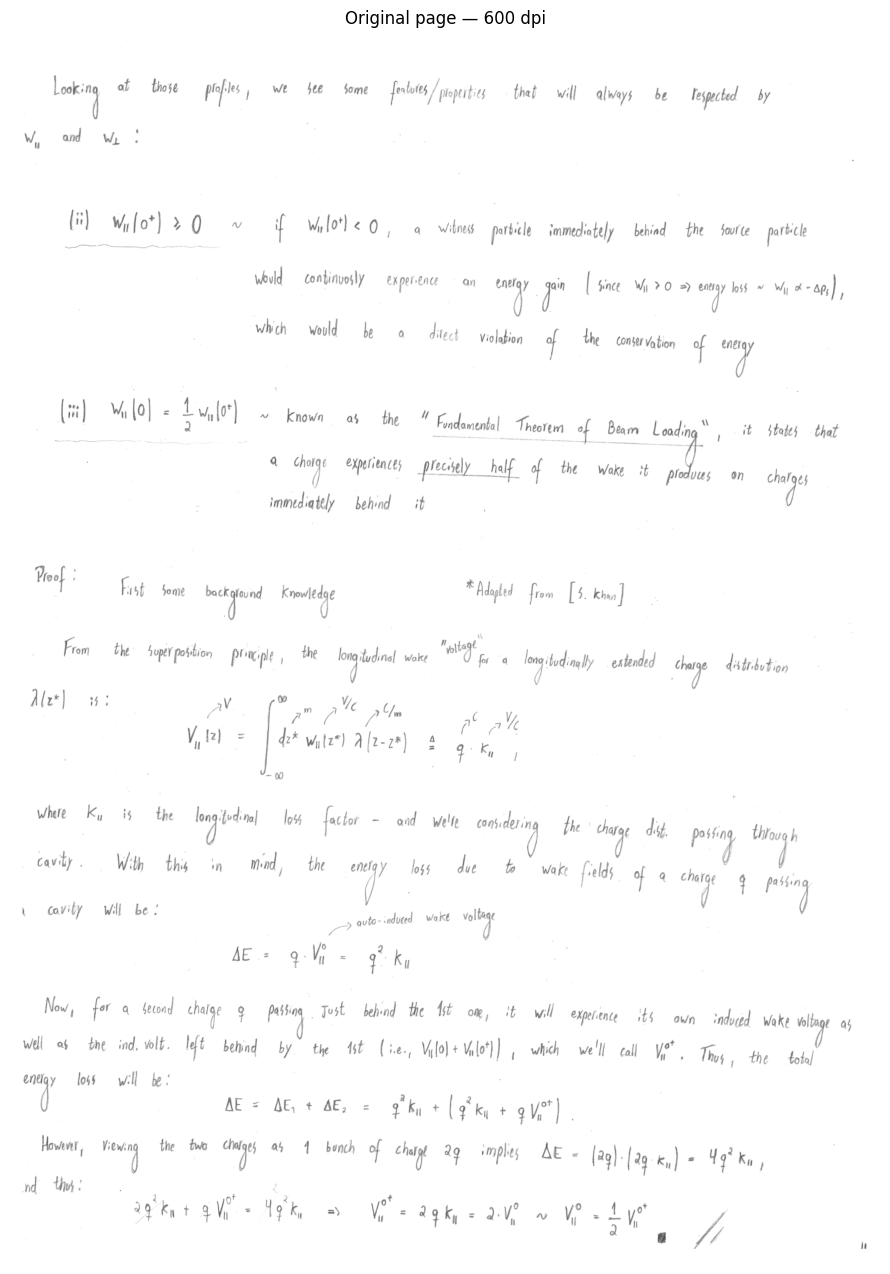

In [42]:
show_image(
    image_gray,
    title=f"Original page — {TEST_DPI} dpi",
)

### Inspect basic information

In [43]:
height, width = image_gray.shape

print(f"Width:  {width} pixels")
print(f"Height: {height} pixels")
print(f"Total pixels: {image_gray.size:,}")
print(f"Memory: {image_gray.nbytes / 1024**2:.1f} MB")
print(f"Intensity range: {image_gray.min()}–{image_gray.max()}")
print(f"Mean intensity: {image_gray.mean():.1f}")
print(f"Median intensity: {np.median(image_gray):.1f}")

Width:  4959 pixels
Height: 7017 pixels
Total pixels: 34,797,303
Memory: 33.2 MB
Intensity range: 0–255
Mean intensity: 251.9
Median intensity: 255.0


### Inspect the intensity distribution

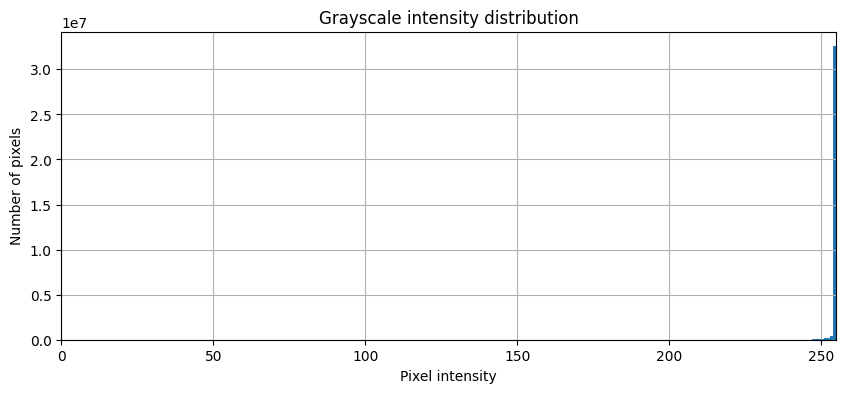

In [44]:
plt.figure(figsize=(10, 4))

plt.hist(
    image_gray.ravel(),
    bins=256,
    range=(0, 255),
)

plt.title("Grayscale intensity distribution")
plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")
plt.xlim(0, 255)
plt.grid()
plt.show()

### Select a representative crop

Testing filters on a crop will be much faster than repeatedly processing the complete 600 dpi page.

Crop shape: (1214, 4513)


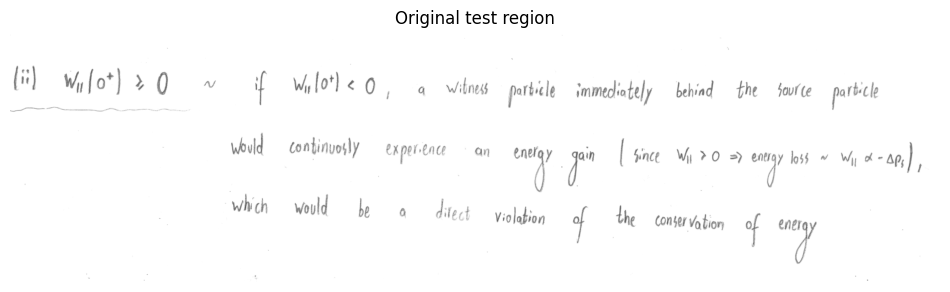

In [66]:
# Crop boundaries as fractions of the page size.
X_START = 0.065
X_END = 0.975
Y_START = 0.12
Y_END = 0.293

x_start = round(width * X_START)
x_end = round(width * X_END)
y_start = round(height * Y_START)
y_end = round(height * Y_END)

test_crop = image_gray[
    y_start:y_end,
    x_start:x_end,
]

print(f"Crop shape: {test_crop.shape}")

show_image(
    test_crop,
    title="Original test region",
    max_width=1800,
)

## 3. Contrast Enhancing